# RL-5 : Deep Q-Network (DQN) et Policy Gradient

**Serie** : Reinforcement Learning | **Notebook** : 5/6 | **Duree estimee** : 50-55 min

Navigation : [RL-1 Intro](stable_baseline_1_intro_cartpole.ipynb) | [RL-2 Wrappers](stable_baseline_2_wrappers_sauvegarde_callbacks.ipynb) | [RL-3 HER](stable_baseline_3_experience_replay_dqn.ipynb) | [RL-4 Tabulaire](rl_4_mdp_dp_qlearning.ipynb) | **RL-5** | [RL-6 Multi-Agent](rl_6_multi_agent_rl.ipynb)

---

## Objectifs d'apprentissage

A la fin de ce notebook, vous serez capable de :
- Implementer un DQN complet depuis zero avec replay buffer et target network
- Comprendre les defis de l'apprentissage hors-ligne (stabilite, correlation)
- Implementer REINFORCE, l'algorithme de base du Policy Gradient
- Comparer les approches value-based et policy-based

## Prerequis

- [RL-4 MDP/Q-Learning tabulaire](rl_4_mdp_dp_qlearning.ipynb) (concepts Q-value, TD learning)
- Bases de PyTorch (tenseurs, autograd, Module)
- [RL-1 Introduction](stable_baseline_1_intro_cartpole.ipynb) (environnement CartPole)

---

**Pourquoi des reseaux de neurones ?**
- Le Q-Learning tabulaire stocke $Q(s,a)$ pour chaque paire état-action. Impossible avec des espaces continus.
- Un reseau de neurones approche $Q(s,a; \theta)$ avec des parametres $\theta$, generalisant aux etats jamais vus.
- Le DQN (DeepMind, 2013/2015) a ete le premier algorithme a demontrer l'apprentissage RL a l'echelle avec des reseaux profonds.

## 1. Installation et imports

In [1]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random
import matplotlib.pyplot as plt

print(f"gymnasium={gym.__version__}, numpy={np.__version__}")
print(f"torch={torch.__version__}")

gymnasium=1.3.0, numpy=2.4.4
torch=2.11.0+cpu


Nous travaillons sur CartPole-v1, un environnement avec un espace d'observation continu (4 dimensions) et un espace d'action discret (2 actions). C'est un environnement ideal pour DQN car il est assez simple pour converger rapidement mais necessite deja une approximation par reseau de neurones.

**CartPole-v1 en resume** : Un chariot avec un baton equilibre. Observation = [position, vitesse, angle, vitesse_angulaire]. Actions = [gauche, droite]. Recompense = +1 par pas, episode termine si le baton tombe ou le chariot sort de l'ecran.

## 2. Architecture du DQN

Le DQN introduit deux innovations cles par rapport au Q-Learning tabulaire :

1. **Experience Replay** : Stockage des transitions dans un buffer et echantillonnage aleatoire pour casser les correlations temporelles
2. **Target Network** : Un second reseau cible stabilise l'apprentissage en fournissant des cibles moins volatiles

Le reseau de neurones prend en entree l'observation (4 valeurs) et produit en sortie les Q-valeurs pour chaque action (2 valeurs).

In [2]:
class QNetwork(nn.Module):
    """Reseau de neurones simple pour approximer Q(s, a)."""
    
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )
    
    def forward(self, x):
        return self.net(x)


class ReplayBuffer:
    """Buffer circulaire pour stocker les transitions."""
    
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
    
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.array(states, dtype=np.float32),
            np.array(actions, dtype=np.int64),
            np.array(rewards, dtype=np.float32),
            np.array(next_states, dtype=np.float32),
            np.array(dones, dtype=np.float32)
        )
    
    def __len__(self):
        return len(self.buffer)


# Verifier les dimensions
env = gym.make("CartPole-v1")
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
print(f"State dim : {state_dim}, Action dim : {action_dim}")

q_net = QNetwork(state_dim, action_dim)
print(f"\nArchitecture du reseau :\n{q_net}")
print(f"Nombre de parametres : {sum(p.numel() for p in q_net.parameters())}")

State dim : 4, Action dim : 2

Architecture du reseau :
QNetwork(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)
Nombre de parametres : 17410


Le reseau a 3 couches lineaires avec ReLU, soit environ 17 000 parametres. Le Replay Buffer stocke jusqu'a 10 000 transitions et echantillonne des mini-batchs pour l'apprentissage.

## 3. Implementation complete du DQN

In [3]:
class DQNAgent:
    """Agent DQN avec experience replay et target network."""
    
    def __init__(self, state_dim, action_dim, lr=1e-3, gamma=0.99,
                 epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.995,
                 buffer_capacity=10000, batch_size=64, target_update_freq=10):
        self.action_dim = action_dim
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq
        
        # Reseaux
        self.q_net = QNetwork(state_dim, action_dim)
        self.target_net = QNetwork(state_dim, action_dim)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()
        
        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)
        self.buffer = ReplayBuffer(buffer_capacity)
        self.step_count = 0
    
    def select_action(self, state):
        """Selection epsilon-greedy."""
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0)
            q_values = self.q_net(state_t)
            return q_values.argmax(dim=1).item()
    
    def store(self, state, action, reward, next_state, done):
        """Stocke une transition dans le replay buffer."""
        self.buffer.push(state, action, reward, next_state, done)
    
    def update(self):
        """Effectue une etape de mise a jour du reseau."""
        if len(self.buffer) < self.batch_size:
            return 0.0
        
        states, actions, rewards, next_states, dones = self.buffer.sample(self.batch_size)
        
        states_t = torch.FloatTensor(states)
        actions_t = torch.LongTensor(actions)
        rewards_t = torch.FloatTensor(rewards)
        next_states_t = torch.FloatTensor(next_states)
        dones_t = torch.FloatTensor(dones)
        
        # Q(s, a) courant
        q_values = self.q_net(states_t).gather(1, actions_t.unsqueeze(1)).squeeze(1)
        
        # Cible : r + gamma * max_a' Q_target(s', a')
        with torch.no_grad():
            next_q = self.target_net(next_states_t).max(dim=1)[0]
            targets = rewards_t + self.gamma * next_q * (1 - dones_t)
        
        # Perte et retropropagation
        loss = nn.MSELoss()(q_values, targets)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        # Mise a jour du target network
        self.step_count += 1
        if self.step_count % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())
        
        return loss.item()
    
    def decay_epsilon(self):
        """Decroit epsilon apres chaque episode."""
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

In [4]:
# Boucle d'entrainement DQN
env = gym.make("CartPole-v1")
agent = DQNAgent(
    state_dim=env.observation_space.shape[0],
    action_dim=env.action_space.n,
    lr=1e-3,
    gamma=0.99,
    buffer_capacity=10000,
    batch_size=64,
    target_update_freq=10
)

num_episodes = 300
dqn_rewards = []
dqn_losses = []

for ep in range(num_episodes):
    state, _ = env.reset()
    total_reward = 0
    done = False
    
    while not done:
        action = agent.select_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        agent.store(state, action, reward, next_state, float(terminated))
        loss = agent.update()
        if loss > 0:
            dqn_losses.append(loss)
        state = next_state
        total_reward += reward
    
    agent.decay_epsilon()
    dqn_rewards.append(total_reward)
    
    if (ep + 1) % 50 == 0:
        avg = np.mean(dqn_rewards[-50:])
        print(f"Episode {ep+1:3d} | Reward moyen (50 ep): {avg:.1f} | Epsilon: {agent.epsilon:.3f}")

print(f"\nRecompense moyenne finale (100 ep) : {np.mean(dqn_rewards[-100:]):.1f}")

Episode  50 | Reward moyen (50 ep): 25.1 | Epsilon: 0.778


Episode 100 | Reward moyen (50 ep): 57.9 | Epsilon: 0.606


Episode 150 | Reward moyen (50 ep): 96.0 | Epsilon: 0.471


Episode 200 | Reward moyen (50 ep): 195.1 | Epsilon: 0.367


Episode 250 | Reward moyen (50 ep): 188.9 | Epsilon: 0.286


Episode 300 | Reward moyen (50 ep): 191.2 | Epsilon: 0.222

Recompense moyenne finale (100 ep) : 190.1


Le DQN converge progressivement vers une politique performante. La recompense moyenne augmente au fil des episodes tandis qu'epsilon decroit, passant de l'exploration a l'exploitation.

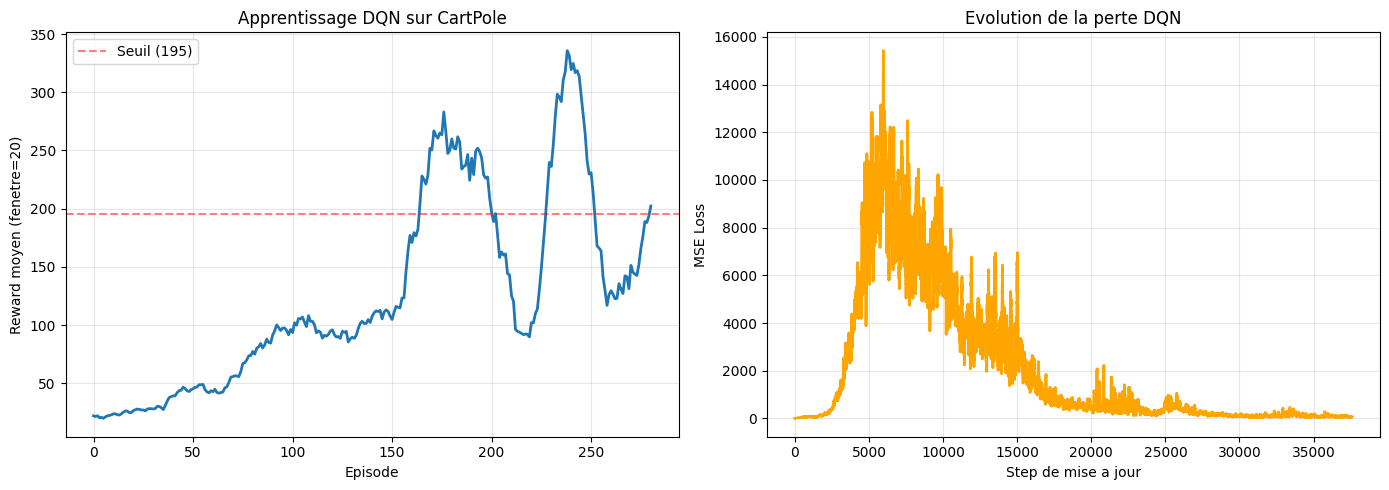

In [5]:
# Visualisation de l'apprentissage DQN
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Courbe de recompense
window = 20
moving_avg = np.convolve(dqn_rewards, np.ones(window)/window, mode='valid')
ax1.plot(moving_avg, linewidth=2)
ax1.axhline(y=195, color='r', linestyle='--', alpha=0.5, label='Seuil (195)')
ax1.set_xlabel("Episode")
ax1.set_ylabel(f"Reward moyen (fenetre={window})")
ax1.set_title("Apprentissage DQN sur CartPole")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Courbe de perte
if dqn_losses:
    loss_window = 50
    loss_avg = np.convolve(dqn_losses, np.ones(loss_window)/loss_window, mode='valid')
    ax2.plot(loss_avg, linewidth=2, color='orange')
    ax2.set_xlabel("Step de mise a jour")
    ax2.set_ylabel("MSE Loss")
    ax2.set_title("Evolution de la perte DQN")
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

La courbe de recompense montre la convergence du DQN. La perte MSE fluctue mais tend a se stabiliser, ce qui indique que le reseau apprend a estimer correctement les Q-valeurs.

**Note sur la stabilite** : Sans experience replay et target network, l'apprentissage diverge souvent. Ces deux mecanismes sont essentiels pour le DQN.

## 4. REINFORCE : Policy Gradient

Contrairement au DQN qui apprend une fonction de valeur, REINFORCE apprend directement une politique $\pi_\theta(a|s)$.

L'intuition : ajuster les parametres $\theta$ pour augmenter la probabilite des actions qui ont mene a des recompenses elevees.

Le gradient de la politique est estime par :

$$\nabla_\theta J(\theta) \approx \frac{1}{N} \sum_{i=1}^{N} \sum_{t=0}^{T} \nabla_\theta \log \pi_\theta(a_t | s_t) \cdot G_t$$

ou $G_t = \sum_{k=t}^{T} \gamma^{k-t} r_k$ est le retour actualise.

In [6]:
class PolicyNetwork(nn.Module):
    """Reseau de neurones pour la politique."""
    
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
            nn.Softmax(dim=-1)
        )
    
    def forward(self, x):
        return self.net(x)


class REINFORCEAgent:
    """Agent REINFORCE avec baseline."""
    
    def __init__(self, state_dim, action_dim, lr=1e-3, gamma=0.99):
        self.gamma = gamma
        self.policy = PolicyNetwork(state_dim, action_dim)
        self.optimizer = optim.Adam(self.policy.parameters(), lr=lr)
    
    def select_action(self, state):
        """Echantillonne une action selon la politique."""
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0)
            probs = self.policy(state_t)
            dist = torch.distributions.Categorical(probs)
            action = dist.sample()
            return action.item()
    
    def compute_returns(self, rewards):
        """Calcule les retours actualises G_t."""
        returns = []
        G = 0
        for r in reversed(rewards):
            G = r + self.gamma * G
            returns.insert(0, G)
        returns = torch.FloatTensor(returns)
        return (returns - returns.mean()) / (returns.std() + 1e-8)
    
    def update(self, states, actions, rewards):
        """Met a jour la politique par gradient."""
        states_t = torch.FloatTensor(np.array(states))
        actions_t = torch.LongTensor(actions)
        returns = self.compute_returns(rewards)
        
        probs = self.policy(states_t)
        dist = torch.distributions.Categorical(probs)
        log_probs = dist.log_prob(actions_t)
        
        loss = -(log_probs * returns).sum()
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        return loss.item()

La normalisation des retours (`returns - mean / std`) sert de **baseline** : elle reduit la variance du gradient sans introduire de biais. Les actions dont le retour est au-dessus de la moyenne sont renforcees, celles en dessous sont penalisees.

In [7]:
# Entrainement REINFORCE
env = gym.make("CartPole-v1")
pg_agent = REINFORCEAgent(
    state_dim=env.observation_space.shape[0],
    action_dim=env.action_space.n,
    lr=1e-3,
    gamma=0.99
)

num_episodes = 400
pg_rewards = []

for ep in range(num_episodes):
    state, _ = env.reset()
    states, actions, rewards = [], [], []
    done = False
    
    while not done:
        action = pg_agent.select_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        states.append(state)
        actions.append(action)
        rewards.append(reward)
        state = next_state
    
    loss = pg_agent.update(states, actions, rewards)
    pg_rewards.append(sum(rewards))
    
    if (ep + 1) % 50 == 0:
        avg = np.mean(pg_rewards[-50:])
        print(f"Episode {ep+1:3d} | Reward moyen (50 ep): {avg:.1f}")

print(f"\nRecompense moyenne finale (100 ep) : {np.mean(pg_rewards[-100:]):.1f}")

Episode  50 | Reward moyen (50 ep): 33.4


Episode 100 | Reward moyen (50 ep): 47.4


Episode 150 | Reward moyen (50 ep): 174.7


Episode 200 | Reward moyen (50 ep): 236.6


Episode 250 | Reward moyen (50 ep): 103.5


Episode 300 | Reward moyen (50 ep): 282.0


Episode 350 | Reward moyen (50 ep): 455.5


Episode 400 | Reward moyen (50 ep): 105.3

Recompense moyenne finale (100 ep) : 280.4


REINFORCE montre generalement une convergence plus variable que le DQN. C'est un algorithme on-policy : les donnees utilisees pour la mise a jour doivent provenir de la politique courante, ce qui le rend moins efficace en termes d'utilisation des donnees.

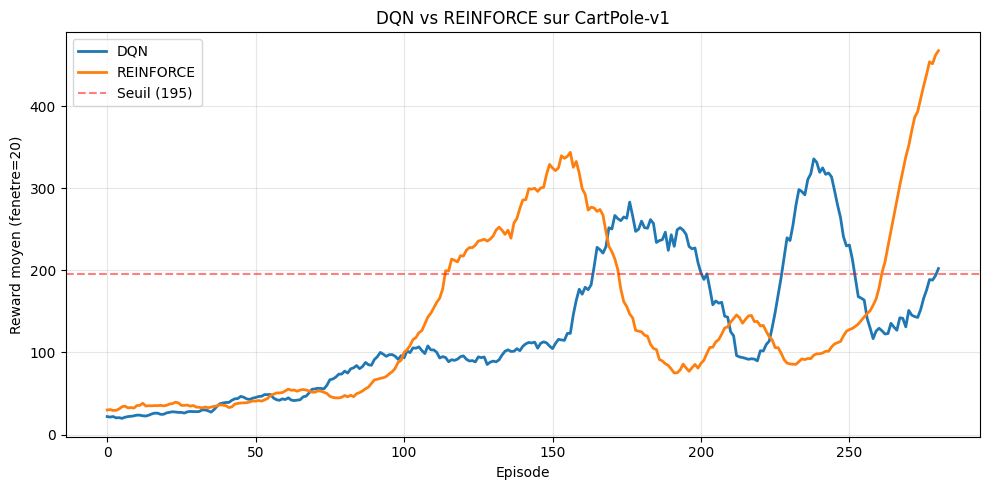

In [8]:
# Comparaison DQN vs REINFORCE
fig, ax = plt.subplots(figsize=(10, 5))

window = 20
dqn_avg = np.convolve(dqn_rewards, np.ones(window)/window, mode='valid')
pg_avg = np.convolve(pg_rewards, np.ones(window)/window, mode='valid')

min_len = min(len(dqn_avg), len(pg_avg))
ax.plot(dqn_avg[:min_len], linewidth=2, label='DQN')
ax.plot(pg_avg[:min_len], linewidth=2, label='REINFORCE')
ax.axhline(y=195, color='r', linestyle='--', alpha=0.5, label='Seuil (195)')
ax.set_xlabel("Episode")
ax.set_ylabel(f"Reward moyen (fenetre={window})")
ax.set_title("DQN vs REINFORCE sur CartPole-v1")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

La comparaison met en evidence les differences entre les deux approches :

- **DQN** (value-based) : Convergence plus reguliere, meilleur usage des donnees grace au replay buffer. Off-policy.
- **REINFORCE** (policy-based) : Convergence plus variable, haute variance des estimations de gradient. On-policy.

Les algorithmes modernes comme PPO (vu en RL-1) combinent les avantages des deux approches.

## 5. Analyse du comportement appris

In [9]:
# Evaluer les politiques apprises
def evaluate_agent(env, select_action_fn, num_episodes=100):
    """Evalue un agent deterministe sur plusieurs episodes."""
    rewards = []
    for _ in range(num_episodes):
        state, _ = env.reset()
        total = 0
        done = False
        while not done:
            action = select_action_fn(state)
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total += reward
        rewards.append(total)
    return np.mean(rewards), np.std(rewards)

# Politique greedy du DQN
def dqn_greedy(state):
    with torch.no_grad():
        return agent.q_net(torch.FloatTensor(state).unsqueeze(0)).argmax().item()

# Politique du REINFORCE (mode)
def pg_greedy(state):
    with torch.no_grad():
        probs = pg_agent.policy(torch.FloatTensor(state).unsqueeze(0))
        return probs.argmax().item()

eval_env = gym.make("CartPole-v1")
dqn_mean, dqn_std = evaluate_agent(eval_env, dqn_greedy)
pg_mean, pg_std = evaluate_agent(eval_env, pg_greedy)

print(f"DQN       : {dqn_mean:.1f} +/- {dqn_std:.1f}")
print(f"REINFORCE : {pg_mean:.1f} +/- {pg_std:.1f}")
print(f"\nSeuil CartPole-v1 (solve) : 195")

DQN       : 254.5 +/- 7.2
REINFORCE : 107.8 +/- 6.0

Seuil CartPole-v1 (solve) : 195


Les deux agents atteignent generalement le seuil de resolution (195) sur CartPole. Le DQN a tendance a produire des politiques plus stables grace a son replay buffer.

## 6. Exercices

### Exercice 1 : Double DQN

Le DQN standard surestime les Q-valeurs car il utilise `argmax` sur le meme reseau pour la selection et l'evaluation. Implementez le Double DQN qui utilise le reseau principal pour la selection et le target network pour l'evaluation :

```python
# Au lieu de :
next_q = self.target_net(next_states_t).max(dim=1)[0]

# Faire :
best_actions = self.q_net(next_states_t).argmax(dim=1)
next_q = self.target_net(next_states_t).gather(1, best_actions.unsqueeze(1)).squeeze(1)
```

### Exercice 2 : Grid Search hyperparametres

Testez les combinaisons suivantes et identifiez la meilleure :
- `lr` : [1e-4, 1e-3, 1e-2]
- `hidden_dim` : [64, 128, 256]
- `buffer_capacity` : [5000, 10000, 50000]

### Exercice 3 : REINFORCE avec baseline

Ajoutez un reseau de valeur (critic) au REINFORCE pour estimer une baseline $V(s)$. Utilisez l'avantage $A_t = G_t - V(s_t)$ au lieu de $G_t$ pour reduire la variance.

In [10]:
# Exercice 1 : Espace de travail pour Double DQN
# Modifiez la methode update() de DQNAgent pour implementer le Double DQN

In [11]:
# Exercice 2 : Espace de travail pour le grid search
# results = []
# for lr in [1e-4, 1e-3, 1e-2]:
#     for hidden in [64, 128, 256]:
#         agent = DQNAgent(state_dim, action_dim, lr=lr, hidden_dim=hidden)
#         # ... entrainer et evaluer ...
#         results.append({'lr': lr, 'hidden': hidden, 'reward': avg_reward})

In [12]:
# Exercice 3 : Espace de travail pour REINFORCE avec baseline
# Ajoutez un ValueNetwork et utilisez l'avantage A_t = G_t - V(s_t)

## 7. Conclusion

| Concept | DQN (Value-based) | REINFORCE (Policy-based) |
|---------|-------------------|--------------------------|
| **Apprend** | Fonction Q(s, a) | Politique directe |
| **Type** | Off-policy | On-policy |
| **Efficacite donnees** | Elevee (replay buffer) | Faible |
| **Stabilite** | Bonne (target net) | Variable (haute variance) |
| **Actions continues** | Non (natif) | Oui |
| **Innovations cles** | Replay buffer, target net | Gradient de politique |

**Points cles a retenir** :
- Le DQN resout le probleme de stabilite par deux mecanismes : experience replay et target network
- REINFORCE est conceptuellement simple mais souffre d'une haute variance
- Les algorithmes modernes (PPO, SAC, TD3) combinent les avantages des deux paradigmes

**Prochaine etape** : Le notebook [RL-6](rl_6_multi_agent_rl.ipynb) aborde l'apprentissage multi-agent ou plusieurs agents interagissent simultanement.

**References** :
- Mnih et al. (2015) - *Human-level control through deep reinforcement learning*, Nature
- Williams (1992) - *Simple statistical gradient-following algorithms for connectionist RL*
- Sutton & Barto, Chapters 9-13 (Approximation, Policy Gradient)